In [1]:
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt

from dataset import DataOps
from trainer_reg import TrainerReg
from reg_model import SensorRegressor

mpl.rcParams["axes.titlesize"] = 12
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["legend.title_fontsize"] = 10

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dops = DataOps()

In [3]:
targets, preds = [], []

for i in range(4):
    sl, sr = i*2, i*2+1

    dl_train, dl_val, dl_test, _ = dops.build_dataloaders(
        sl, sr, batch_size=16, type="reg"
    )

    model = SensorRegressor(input_dim=20)

    trainer = TrainerReg(
        model,
        dl_train,
        dl_val,
        dl_test,
        lr=0.001,
        epochs=200,
        patience=5,
        device=device,
        save_path=f"best_reg_model_{sl}_{sr}.pt"
    )

    print(f"\nTraining on sensors {sl} and {sr}\n")
    trainer.train()
    test_loss, all_preds, all_targets = trainer.test()
    targets.append(all_targets)
    preds.append(all_preds)


Training on sensors 0 and 1

Epoch 001 | Train Loss 4.1025 | Val Loss 2.6501
Best model saved.
Epoch 002 | Train Loss 0.6793 | Val Loss 0.2586
Best model saved.
Epoch 003 | Train Loss 0.1606 | Val Loss 0.0291
Best model saved.
Epoch 004 | Train Loss 0.1251 | Val Loss 0.0578
Epoch 005 | Train Loss 0.1148 | Val Loss 0.0355
Epoch 006 | Train Loss 0.0812 | Val Loss 0.0395
Epoch 007 | Train Loss 0.0851 | Val Loss 0.0265
Best model saved.
Epoch 008 | Train Loss 0.1177 | Val Loss 0.0209
Best model saved.
Epoch 009 | Train Loss 0.1556 | Val Loss 0.0486
Epoch 010 | Train Loss 0.0521 | Val Loss 0.0278
Epoch 011 | Train Loss 0.0841 | Val Loss 0.0158
Best model saved.
Epoch 012 | Train Loss 0.0589 | Val Loss 0.0337
Epoch 013 | Train Loss 0.0399 | Val Loss 0.0388
Epoch 014 | Train Loss 0.0426 | Val Loss 0.0228
Epoch 015 | Train Loss 0.0749 | Val Loss 0.0061
Best model saved.
Epoch 016 | Train Loss 0.0678 | Val Loss 0.0306
Epoch 017 | Train Loss 0.0388 | Val Loss 0.0099
Epoch 018 | Train Loss 0.039

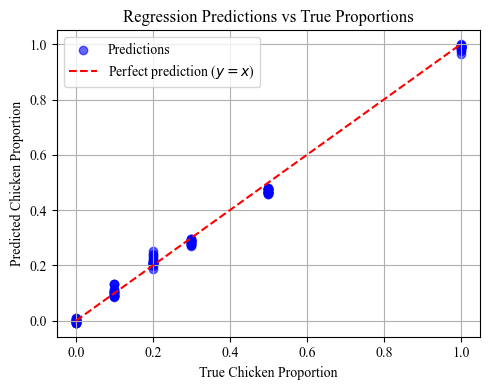

In [4]:
best_idx = 0
true_vals = targets[best_idx].squeeze().numpy()
pred_vals = preds[best_idx].squeeze().numpy()

plt.figure(figsize=(5, 4))
plt.title("Regression Predictions vs True Proportions")

plt.scatter(true_vals, pred_vals, color="blue", alpha=0.6, label="Predictions")

plt.plot([0, 1], [0, 1],
         color="red",
         linestyle="--",
         label=r"Perfect prediction ($y=x$)")

plt.xlabel("True Chicken Proportion")
plt.ylabel("Predicted Chicken Proportion")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"figures/reg_line.pdf", format="pdf", bbox_inches="tight")
plt.show()